# Set Up

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "svg"
import matplotlib.gridspec as gridspec

In [2]:
from tmd_model import *
from kubo import *

## Specify Parameters

In [3]:
cutoff = 2 #number of momentum space scattering processes allowed

In [4]:
# set twist angle
θ = 5*np.pi/180 #radians

#doping and temperature
mu = -60+4.828263103620056 #meV ~gap due to scalar potential
T = 10 #K

#heterostrain
displacements = np.linspace(-69,69,139)
eps = 0.001
strain_dir = 0 #radians

#material parameters for MoTe2 (are given in tmd_model.py)
t_inter = -8.5

In [5]:
# %%time
# res = 60 #runtime scales as res^2;
Nw = 139 #number of frequency steps
eta = 5j #meV
Ws = np.linspace(0.1,50,Nw)+eta*np.ones(Nw)
# s = np.zeros((np.shape(displacements)[0], 4,4,Nw),dtype=complex)

# for i in range(np.shape(displacements)[0]): #parameter choices
#     print(i)
#     displacement = displacements[i]
#     _, _, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
#     xs = (np.arange(res) + 0.5) / res - 0.5
#     ys = (np.arange(res) + 0.5) / res - 0.5
#     for x in range(0,res,1): #kx range
#         for y in range(0,res,1): #ky range
#             k = xs[x]*G1 + ys[y]*G2 #parallelogram BZ
#             for valley in [-1,1]: #valley sum
#                 s[i] += kubo_fast(k,θ,mu,T,Ws,cutoff,valley=valley,t_inter=t_inter,eps=eps,strain_dir=strain_dir,displacement=displacement)
#     A_BZ = np.abs(np.linalg.det(np.column_stack([G1,G2]))) #BZ area
#     scale = (A_BZ/(2*np.pi)**2)/res**2 #n_pts
#     s[i] *= scale

## Zero interlayer coupling

In [6]:
t_inter = 0

In [7]:
# %%time


# s0 = np.zeros((np.shape(displacements)[0], 4,4,Nw),dtype=complex)
# for i in range(np.shape(displacements)[0]): #parameter choices
#     print(i)
#     displacement = displacements[i]
#     _, _, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
#     xs = (np.arange(res) + 0.5) / res - 0.5
#     ys = (np.arange(res) + 0.5) / res - 0.5
#     for x in range(0,res,1): #kx range
#         for y in range(0,res,1): #ky range
#             k = xs[x]*G1 + ys[y]*G2 #parallelogram BZ
#             for valley in [-1,1]: #valley sum
#                 s0[i] += kubo_fast(k,θ,mu,T,Ws,cutoff,valley=valley,t_inter=t_inter,eps=eps,strain_dir=strain_dir,displacement=displacement)
#     A_BZ = np.abs(np.linalg.det(np.column_stack([G1,G2]))) #BZ area
#     scale = (A_BZ/(2*np.pi)**2)/res**2 #n_pts
#     s0[i] *= scale

## Load data

In [8]:
# np.save("s.npy",s)
# np.save("s0.npy",s0)

In [9]:
s = np.load("s.npy")
s0 = np.load("s0.npy")

## Visualize

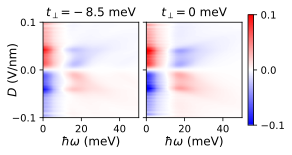

In [10]:
fig = plt.figure(figsize=(4.,2))
gs = gridspec.GridSpec(1,2, figure=fig,
                    height_ratios=[1],
                    width_ratios=[1,1.25],
                    hspace=0.0, wspace=0.07)

Ws = np.real(Ws)

ax = plt.subplot(gs[0,0])
plt.title(r"$t_\perp\!=\!-8.5$ meV")

sp = np.zeros(np.shape(s),dtype=complex)
for i in range(np.shape(displacements)[0]):
    sp[i] = reprocess(s[i])

#plot
thickness = 0.69 #nm for MoTe2
plt.imshow(np.real(1j*sp[:,0,3]),origin="lower",extent=[0,np.real(Ws[-1]),displacements[0]/1000/thickness,displacements[-1]/1000/thickness],aspect=(np.real(Ws[-1]))/(displacements[-1]/1000/thickness-displacements[0]/1000/thickness),interpolation="nearest",vmin=-0.1,vmax=0.1,cmap="bwr")
# plt.colorbar()
plt.xlabel(r"$\hbar\omega$ (meV)",labelpad=2,fontsize=12)
plt.ylabel(r"$D$ (V/nm)",labelpad=-7,fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)



ax = plt.subplot(gs[0,1])
plt.title(r"$t_\perp\!=0$ meV")

sp0 = np.zeros(np.shape(s0),dtype=complex)
for i in range(np.shape(displacements)[0]):
    sp0[i] = reprocess(s0[i])

#plot
thickness = 0.69 #nm for MoTe2
plt.imshow(np.real(1j*sp0[:,0,3]),origin="lower",extent=[0,np.real(Ws[-1]),displacements[0]/1000/thickness,displacements[-1]/1000/thickness],aspect=(np.real(Ws[-1]))/(displacements[-1]/1000/thickness-displacements[0]/1000/thickness),interpolation="nearest",vmin=-0.1,vmax=0.1,cmap="bwr")
cbar = plt.colorbar()
cbar.set_ticks([-0.1,0,0.1])
plt.xlabel(r"$\hbar\omega$ (meV)",labelpad=2,fontsize=12)
# plt.ylabel(r"$D$ (V/nm)",labelpad=-5,fontsize=12)
plt.xticks(fontsize=10)
plt.yticks([-0.1,0,0.1],[],fontsize=10)

plt.savefig("MoTe2-joined.pdf",dpi=600,bbox_inches="tight")
plt.show()
plt.close()

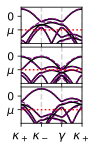

In [11]:
fig = plt.figure(figsize=(1.1,2.1))
gs = gridspec.GridSpec(3,1, figure=fig,
                    height_ratios=[1,1,1],
                    width_ratios=[1],
                    hspace=0.1, wspace=0)


#band structures

t_inters = [-8.5,0]

res = 200

E0 = 4.828263103620056

size = 2 * (2*cutoff+1)**2

ks = np.linspace(0,1,res*3)
eigs = np.zeros((res*3,size)) #50 for cutoff = 2, 98 for cutoff = 3
k_points = np.zeros((res*3,2))

K, Kp, G1, G2 = geometry(θ,eps=eps,strain_dir=strain_dir)
G = (G1 - G2)/2 #not (0,0) !
k_points[:res]   = np.outer(K,np.ones(res)).T + np.outer(Kp-K,np.linspace(0,1,res)).T
k_points[res:2*res] = np.outer(Kp,np.ones(res)).T + np.outer(G-Kp,np.linspace(0,1,res)).T
k_points[2*res:] = np.outer(G,np.ones(res)).T+ np.outer(K-G,np.linspace(0,1,res)).T



ax = plt.subplot(gs[0,0])

displacement = 69

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[1],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.5,c="k")
plt.plot(ks,eigs[:,0]-E0,lw=1.5,c="k",label=r"$t_\perp\!\!=80$ meV")

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[0],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.2,ls="dashed",c="purple")
plt.plot(ks,eigs[:,0]-E0,lw=1.2,ls="dashed",c="purple",label=r"$t_\perp\!\!=0$ meV")

# plt.title(r"$t\!_\perp\!\!=\!$"+str(int(t_inters[i]*1000))+r"$\,$meV",fontsize=13)
plt.ylim(-120,40)
# plt.ylabel(r"$E$",fontsize=13,labelpad=0)
for j in range(0,4,1):
  plt.axvline(j/3,ls="dashed",c="lightgray",zorder=0)
plt.xticks([0,1/3,2/3,1],[],fontsize=12)
plt.yticks([0,-60],["0",r"$\mu$"],fontsize=11)
plt.xlim(0,1)
plt.axhline(-60,c="red",ls="dotted")
# plt.legend(fontsize=10.5,loc=9,framealpha=1)


ax = plt.subplot(gs[1,0])

displacement = 0

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[1],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.5,c="k")
plt.plot(ks,eigs[:,0]-E0,lw=1.5,c="k",label=r"$t_\perp\!\!=80$ meV")

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[0],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.2,ls="dashed",c="purple")
plt.plot(ks,eigs[:,0]-E0,lw=1.2,ls="dashed",c="purple",label=r"$t_\perp\!\!=0$ meV")

# plt.title(r"$t\!_\perp\!\!=\!$"+str(int(t_inters[i]*1000))+r"$\,$meV",fontsize=13)
plt.ylim(-120,40)
# plt.ylabel(r"$E$",fontsize=13,labelpad=0)
for j in range(0,4,1):
  plt.axvline(j/3,ls="dashed",c="lightgray",zorder=0)
plt.xticks([0,1/3,2/3,1],[],fontsize=12)
plt.yticks([0,-60],["0",r"$\mu$"],fontsize=11)
plt.xlim(0,1)
plt.axhline(-60,c="red",ls="dotted")
# plt.legend(fontsize=10.5,loc=9,framealpha=1)


ax = plt.subplot(gs[2,0])

displacement = -69

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[1],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.5,c="k")
plt.plot(ks,eigs[:,0]-E0,lw=1.5,c="k",label=r"$t_\perp\!\!=80$ meV")

for j in range(0,3*res,1):
    eigs[j] = np.linalg.eigvalsh(H_valley(k_points[j],θ,cutoff,t_inter=t_inters[0],valley=+1, eps=eps,strain_dir=strain_dir,displacement=displacement))
plt.plot(ks,eigs-E0,lw=1.2,ls="dashed",c="purple")
plt.plot(ks,eigs[:,0]-E0,lw=1.2,ls="dashed",c="purple",label=r"$t_\perp\!\!=0$ meV")

# plt.title(r"$t\!_\perp\!\!=\!$"+str(int(t_inters[i]*1000))+r"$\,$meV",fontsize=13)
plt.ylim(-120,40)
# plt.ylabel(r"$E$",fontsize=13,labelpad=0)
for j in range(0,4,1):
  plt.axvline(j/3,ls="dashed",c="lightgray",zorder=0)
plt.xticks([0,1/3,2/3,1],[r"$\kappa_+$",r"$\kappa_-$",r"$\gamma$",r"$\kappa_+$"],fontsize=12)
plt.yticks([0,-60],["0",r"$\mu$"],fontsize=11)
plt.xlim(0,1)
plt.axhline(-60,c="red",ls="dotted")
# plt.legend(fontsize=10.5,loc=9,framealpha=1)



plt.savefig("bands.pdf",bbox_inches="tight")